In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset,DataLoader
from torch import autograd
from torch.autograd import Variable
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from IPython.display import clear_output
import matplotlib.pyplot as plt
from datetime import datetime
import datetime as dt
import sys
import os
# import umap
import argparse
import time

In [2]:
import numpy as np
import pandas as pd
import torch
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset,DataLoader, WeightedRandomSampler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score, f1_score
import glob

In [3]:
from sklearn.metrics import (
    roc_auc_score, f1_score,fbeta_score, confusion_matrix
)

In [23]:
if torch.cuda.is_available():
    device=torch.device('cpu')
else:
    device=torch.device('cpu')

In [24]:
def validation_func(data,model,criterion, cutoff=0.5):
    snp=data['snp']
    cli=data['cli']
    y=data['y']
    
    tensor_snp=torch.from_numpy(snp).float().to(device)
    tensor_cli=torch.from_numpy(cli).float().to(device)
    tensor_y=torch.from_numpy(y).float().to(device).view(-1,1)
    
    output=model(tensor_snp, tensor_cli)
    logit_output=torch.sigmoid(output)
    val_loss=criterion(output,tensor_y)
    acc,sen,spe,auc,f1,f2=model_performance_DNN(y,logit_output.cpu().detach().numpy(),cutoff)
    
    val_loss = val_loss.cpu().detach().numpy()
    
    return val_loss, acc, sen, spe, auc,f1,f2, logit_output.cpu().detach().numpy()

In [25]:
# Function for confusion metrics
def check_correct(predict, y):     #Using def enables us to customize our own functions. 
    result = {}
    result['True-Positive'] = 0
    result['True-Negative'] = 0
    result['False-Negative'] = 0
    result['False-Positive'] = 0

    for i in range(len(predict)) :
        if predict[i] == y[i] :
            if y[i] == 0 :
                result['True-Negative'] += 1
            else :
                result['True-Positive'] += 1
        else :
            if y[i] == 0 :
                result['False-Positive'] += 1
            else :
                result['False-Negative'] += 1

    try:
        accuracy=(result['True-Positive']+result['True-Negative'])/len(y)  # Accuracy = correct predictions / all predictions 
        sensitivity=result['True-Positive']/(result['True-Positive']+result['False-Negative']) # TP / TP + FN
        specificity=result['True-Negative']/(result['True-Negative']+result['False-Positive']) # TN / TN + FP
    except ZeroDivisionError:
        print('0 divisionerror')
    
    return accuracy, sensitivity, specificity

In [26]:
# Function for DNN performance
def model_performance_DNN(real,pred,cutoff):
    
    pred_label = np.where(pred>cutoff, 1, 0) # relation to sigmoid activation function
    f1 = f1_score(real, pred_label)
    f2 = fbeta_score(real, pred_label, beta=2)
    #print(pred_label)
    #print(real)
    accuracy, sensitivity, specificity=check_correct(pred_label,real)
    auc = roc_auc_score(real, pred)
    
    df_hypo=pd.DataFrame(pred) # prediction probability
    df_hypo.columns=['hypothesis 1']
    
    df_pred=pd.DataFrame(pred_label) # zero or one 
    df_pred.columns=['prediction']
    
    df_y=pd.DataFrame(real)
    df_y.columns=['y']
    
    pred_result=pd.concat([df_y,df_hypo, df_pred],axis=1)
    
    return accuracy, sensitivity, specificity, auc, f1, f2

In [27]:
def eGFR_cal(Cr,age, sex):
    if sex == 1 :# 여성
        K = 0.7
        alpha = -0.241 
        last = 1.012
    else:# 남성
        K = 0.9
        alpha = -0.302 
        last = 1
    
    eGFR = 142*((min(Cr/K,1))**alpha)*((max(Cr/K,1))**(-1.2))*((0.9938)**age)*last
    return np.round(eGFR,0)

In [28]:
def mk_eGFR_data(clinical_only_raw):
    eGFR_data = []
    for sample in range(len(clinical_only_raw)):
        eGFR_data.append(eGFR_cal(clinical_only_raw.loc[sample,"Cr"], clinical_only_raw.loc[sample,"age"], clinical_only_raw.loc[sample,"F"]))
    return eGFR_data

In [29]:
def mkMBP(cli):
    cli['MBP'] = (2*cli['dia'] + cli['sys'])/3
    cli = cli.drop(columns = ['dia','sys'])
    return cli

In [30]:
class Net1(nn.Module):
    def __init__(self, SNP_FEATURE_NUM, CLI_FEATURE_NUM, T_FEATURE_NUM,pre_model):
        super(Net1,self).__init__()
        
        self.ac=self.activation(acfunc)
        
        Total_linear_block_lst=[]
        
        Total_bn_block_lst=[]
        
        self.snp=nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5),
            nn.BatchNorm1d(16),
            #nn.ELU(),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=3,stride=1),
            nn.Dropout(drop_num),
            nn.Conv1d(16, 32, kernel_size=5),
            nn.BatchNorm1d(32),
            #nn.ELU(),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=3,stride=1),
            nn.Dropout(drop_num),
            nn.Conv1d(32, 32, kernel_size=3),
            nn.BatchNorm1d(32),
            #nn.ELU(),            
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=3,stride=1),
            nn.Dropout(drop_num),            
            nn.Conv1d(32, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            #nn.ELU(),            
            nn.LeakyReLU(),
            nn.AdaptiveMaxPool1d(output_size=1),
            
            nn.Flatten(),
        )
        for i in range(0,Total_num-1,1):
            Total_linear_block_lst.append(nn.Linear(Total_fe_lst[i],Total_fe_lst[i+1]))
            
        for i in range(1,Total_num,1):
            Total_bn_block_lst.append(nn.BatchNorm1d(Total_fe_lst[i]))
            
        self.Total_linear_lst=nn.ModuleList(Total_linear_block_lst)
        
        self.Total_bn_lst=nn.ModuleList(Total_bn_block_lst)
        
        self.dropout = nn.Dropout(drop_num)
        
        self.cli_layer=pre_model
        
        self.last=nn.Linear(Total_fe_lst[-1],1)

    def forward(self,snp, cli):
        snp=snp.view([-1,1,31])
        snp=self.snp(snp)
        
        cli_output=self.cli_layer(cli)
        
        total = torch.cat((snp, cli_output), dim=1)
        
        for i,(l,bn) in enumerate(zip(self.Total_linear_lst,self.Total_bn_lst)):
            total=l(total)
            total=bn(total)
            total=self.ac(total)
            total=self.dropout(total)
        
        out=self.last(total)
        return out
    
    def activation(self,func):
        if func=='elu':
            return nn.ELU()
        elif func=='leaky_relu':
            return nn.LeakyReLU()
        elif func=='gelu':
            return nn.GELU()
        elif func=='swish':
            return nn.SiLU()
        elif func=='soft':
            return F.softplus
        elif func=='mish':
            return nn.Mish()

In [31]:
def linspace(start, end, n):
    print(end)
    step = (end - start) / (n - 1)
    return [start + int(np.round(i * step)) for i in range(n)]

In [32]:
class GenerateData(Dataset):
    def __init__(self,dataset):
        #dataset:dict
        self.snp=torch.from_numpy(dataset['snp']).float()
        self.cli=torch.from_numpy(dataset['cli']).float()
        self.y=torch.from_numpy(dataset['y']).float()
#         self.len=dataset[''].shape[0]
        
    def __getitem__(self,idx):
        data={'snp':self.snp[idx],'cli':self.cli[idx],'y':self.y[idx]}
        return data
    def __len__(self):
        return self.len

In [33]:
class FCNetwork(nn.Module):
    def __init__(self,FEATURE_NUM):
        super(FCNetwork, self).__init__()
        self.pre_part=nn.Sequential(
            nn.Linear(FEATURE_NUM, FEATURE_NUM),
            nn.BatchNorm1d(FEATURE_NUM),
            nn.ELU(),
            nn.Dropout(),
            nn.Linear(FEATURE_NUM, FEATURE_NUM),
            nn.BatchNorm1d(FEATURE_NUM),
            nn.ELU(),
            nn.Dropout(),
            nn.Linear(FEATURE_NUM, FEATURE_NUM),
            nn.BatchNorm1d(FEATURE_NUM),
            nn.ELU(),
            nn.Dropout(),
            nn.Linear(FEATURE_NUM, FEATURE_NUM),
            nn.BatchNorm1d(FEATURE_NUM),
            nn.ELU(),
            nn.Dropout(),  
            
        )
        self.fc4 = nn.Linear(FEATURE_NUM, 1)

    def forward(self, x):
        x=self.pre_part(x)
        out=self.fc4(x)
        return out

In [34]:
PRE_FEATURE_NUM=18
pre_model=FCNetwork(PRE_FEATURE_NUM)
pretraining_path = './Model/Pretrain/best_model_20.h5'

In [35]:
def load_data(file_path,idx,scaler):
    tr_path=os.path.join(file_path,f'Train.csv')
    val_path=os.path.join(file_path,f'Validation.csv')
    test_path=os.path.join(file_path,'Test.csv')
    train_raw=pd.read_csv(tr_path)
    validation_raw=pd.read_csv(val_path)
    test_raw=pd.read_csv(test_path)    

    train_raw = train_raw.dropna().reset_index(drop=True)
    validation_raw = validation_raw.dropna().reset_index(drop=True)
    test_raw = test_raw.dropna().reset_index(drop=True)
    
    # test_raw = pd.concat([train_raw,validation_raw,test_raw]).reset_index(drop=True)
    
    train_raw = mkMBP(train_raw)
    validation_raw = mkMBP(validation_raw)
    test_raw = mkMBP(test_raw)
    
    train_raw['Tg']=np.log(train_raw['Tg'])
    validation_raw['Tg']=np.log(validation_raw['Tg'])
    test_raw['Tg']=np.log(test_raw['Tg'])

    drop_cols=['sample','area']

    sample = pd.concat([train_raw[['sample']],validation_raw[['sample']],test_raw[['sample']]])
    trsample, valsample, tssample = train_raw[['sample','area']],validation_raw[['sample','area']],test_raw[['sample','area']]
    
    train_raw=train_raw.drop(columns=drop_cols)
    validation_raw=validation_raw.drop(columns=drop_cols)
    test_raw=test_raw.drop(columns=drop_cols)
    
    train_x,train_y=train_raw.drop(columns=['progress_DM']),train_raw['progress_DM']
    validation_x,validation_y=validation_raw.drop(columns=['progress_DM']),validation_raw['progress_DM']
    test_x,test_y=test_raw.drop(columns=['progress_DM']),test_raw['progress_DM']

    train_x['Cr'] = mk_eGFR_data(train_x)
    validation_x['Cr'] = mk_eGFR_data(validation_x)
    test_x['Cr'] = mk_eGFR_data(test_x)
    
    train_x[train_x.columns]=scaler.fit_transform(train_x)
    train_x = train_x.rename(columns = {'Cr':'eGFR'})
    validation_x[validation_x.columns]=scaler.transform(validation_x)
    validation_x = validation_x.rename(columns = {'Cr':'eGFR'})
    test_x[test_x.columns]=scaler.transform(test_x)
    test_x = test_x.rename(columns = {'Cr':'eGFR'})
    
    return (train_x,train_y),(validation_x,validation_y),(test_x,test_y),sample,scaler, trsample, valsample, tssample

In [36]:
def load_data2(file_path,idx,scaler):
    tr_path=os.path.join(file_path,f'Train.csv')
    val_path=os.path.join(file_path,f'Validation.csv')
    test_path=os.path.join(file_path,'Test.csv')
    train_raw=pd.read_csv(tr_path)
    validation_raw=pd.read_csv(val_path)
    test_raw=pd.read_csv(test_path)    

    train_raw = train_raw.dropna().reset_index(drop=True)
    validation_raw = validation_raw.dropna().reset_index(drop=True)
    test_raw = test_raw.dropna().reset_index(drop=True)

    
    train_raw = mkMBP(train_raw)
    validation_raw = mkMBP(validation_raw)
    test_raw = mkMBP(test_raw)
    
    train_raw['Tg']=np.log(train_raw['Tg'])
    validation_raw['Tg']=np.log(validation_raw['Tg'])
    test_raw['Tg']=np.log(test_raw['Tg'])

    drop_cols=['sample','area']

    sample = pd.concat([train_raw[['sample']],validation_raw[['sample']],test_raw[['sample']]])
    
    train_raw=train_raw.drop(columns=drop_cols)
    validation_raw=validation_raw.drop(columns=drop_cols)
    test_raw=test_raw.drop(columns=drop_cols)
    
    train_x,train_y=train_raw.drop(columns=['progress_DM']),train_raw['progress_DM']
    validation_x,validation_y=validation_raw.drop(columns=['progress_DM']),validation_raw['progress_DM']
    test_x,test_y=test_raw.drop(columns=['progress_DM']),test_raw['progress_DM']

    train_x['Cr'] = mk_eGFR_data(train_x)
    validation_x['Cr'] = mk_eGFR_data(validation_x)
    test_x['Cr'] = mk_eGFR_data(test_x)
    
    train_x[train_x.columns]=scaler.transform(train_x)
    train_x = train_x.rename(columns = {'Cr':'eGFR'})
    validation_x[validation_x.columns]=scaler.transform(validation_x)
    validation_x = validation_x.rename(columns = {'Cr':'eGFR'})
    test_x[test_x.columns]=scaler.transform(test_x)
    test_x = test_x.rename(columns = {'Cr':'eGFR'})
    
    return (train_x,train_y),(validation_x,validation_y),(test_x,test_y),sample

In [37]:
from itertools import product

batch_size_list = [1024]
random_state_list = [123]
learning_rate_list = [1e-02]
SNP_num_list = [3]
Total_num_list = [3]
positive_weight_list = [1.7]
dropout_num_list = [0.5]
activation_function_list = ['elu']


combinations = list(product(batch_size_list,random_state_list,learning_rate_list,SNP_num_list,
                            Total_num_list,positive_weight_list,dropout_num_list,activation_function_list))

print(len(combinations))

1


In [38]:
# 디렉터리 경로 지정
directory_path = './Model/Transfer_learning/'

matching_files = glob.glob(os.path.join(directory_path,'best_model_elu_*'))

# Best model 불러오기

In [39]:
criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(8.0))
val_perf = []
test_perf = []
used_columns = ['M','F', 'age', 'waist', 'bmi', 'MBP', 'DM_FH', 'htndiag', 'lipdiag', 'exercise',
       'drink', 'smoke', 'FBS', 'Hba1c', 'WBC', 'Tg', 'ALT', 'eGFR']
for model_num in [1]: 
    file_path='./DATA/'
    scaler=MinMaxScaler()
    train,validation,test, sample, scaler, trsample, valsample, tssample = load_data(file_path,model_num,scaler)
    snp_col = list(train[0].columns[~train[0].columns.isin(used_columns)])
    tr_snp_x,tr_cli_x=train[0][snp_col],train[0][used_columns]
    val_snp_x,val_cli_x=validation[0][snp_col],validation[0][used_columns]
    ts_snp_x,ts_cli_x=test[0][snp_col],test[0][used_columns]
    SNP_FEATURE_NUM=tr_snp_x.shape[1]
    CLI_FEATURE_NUM=tr_cli_x.shape[1]

    
    for hypernum in matching_files:
        print(hypernum)
        SNP_num=int(hypernum.split('layer-')[-1].split('-')[0])
        Total_num=int(hypernum.split('layer-')[-1].split('-')[1].split('_')[0])
        acfunc = hypernum.split('-')[-1].split('.')[0]
        drop_num = float(hypernum.split('-')[-3].split('_')[0])
        SNP_fe_num=64
        Cli_fe_num=CLI_FEATURE_NUM
        Total_fe_num=64+int(Cli_fe_num*1.0)
    
        Total_step=int(Total_fe_num/Total_num)
    
        Total_fe_lst=linspace(1, Total_fe_num, Total_num+1)
        Total_fe_lst.reverse()
        Total_fe_lst.pop()
        
        weighted_pos_weight=hypernum[5]
        
        pre_model=FCNetwork(PRE_FEATURE_NUM).to(device)
        pre_model.load_state_dict(torch.load(pretraining_path, weights_only=True))
        pre_model=pre_model.pre_part
        
        models = Net1(SNP_fe_num, Cli_fe_num, Total_fe_num, pre_model).to(device)
        # for load_link in matching_files:
        matching_files = glob.glob(os.path.join(directory_path,'best_model_elu_*'))
        models.load_state_dict(torch.load(hypernum, weights_only=True))
        models.eval()
    
        tr_set={'snp':tr_snp_x.to_numpy(),'cli':tr_cli_x.to_numpy(),'y':train[1].to_numpy()}
        val_data={'snp':val_snp_x.to_numpy(),'cli':val_cli_x.to_numpy(),'y':validation[1].to_numpy()}
        test_data={'snp':ts_snp_x.to_numpy(),'cli':ts_cli_x.to_numpy(),'y':test[1].to_numpy()}

        trloss, tracc, trsen, trspe, trauc, trf1, trf2, troutput = validation_func(tr_set,models,criterion,cutoff=0.5)
        vloss, vacc, vsen, vspe, vauc, vf1, vf2, voutput = validation_func(val_data,models,criterion,cutoff=0.5)
        tloss, tacc, tsen, tspe, tauc, tf1, tf2, toutput= validation_func(test_data,models,criterion,cutoff=0.5)
    
        val_perf.append([hypernum,vloss, vacc, vsen, vspe, vauc, vf1, vf2])
        test_perf.append([hypernum,tloss, tacc, tsen, tspe, tauc, tf1, tf2])
    
        print(model_num, 'vauc: ',vauc)


./Model/Transfer_learning/best_model_elu_dataset-0_W-1.7_Batch-1024_lr-0.01_layer-3-3_dropout-0.5_random-123_act-elu.h5
82
1 vauc:  0.8937977394079082


In [40]:
val_df = pd.DataFrame(val_perf,columns = ['model','loss','acc','sen','spe','auc','f1','f2'])
test_df = pd.DataFrame(test_perf,columns = ['model','loss','acc','sen','spe','auc','f1','f2'])

In [41]:
val_df.sort_values(by='auc',ascending=False)

,model,loss,acc,sen,spe,auc,f1,f2
0,./Model/Transfer_learning/best_model_elu_...,0.63081175,0.800144,0.836478,0.797935,0.893798,0.324193,0.512524


In [42]:
test_df.sort_values(by='auc',ascending=False)

,model,loss,acc,sen,spe,auc,f1,f2
0,./Model/Transfer_learning/best_model_elu_...,0.6522944,0.798559,0.813291,0.797669,0.874047,0.314951,0.498062


In [43]:
val_num = 0
val_df.iloc[[val_num],:]

,model,loss,acc,sen,spe,auc,f1,f2
0,./Model/Transfer_learning/best_model_elu_...,0.63081175,0.800144,0.836478,0.797935,0.893798,0.324193,0.512524


### KoGES 데이터 샘플명 확보

In [44]:
tr3 = pd.read_csv('./DATA/Train.csv')
val3 = pd.read_csv('./DATA/Validation.csv')
ts3 = pd.read_csv('./DATA/Test.csv')
total3 = pd.concat([tr3,val3,ts3]).reset_index(drop=True)

In [45]:
total3 = mkMBP(total3)
total3['Tg']=np.log(total3['Tg'])
total3['Cr'] = mk_eGFR_data(total3)

In [46]:
total3 = total3[total3['area'] != 'SN'].reset_index(drop=True)
# total3 = total3[total3['area'] == 55].reset_index(drop=True)

In [47]:
len(total3['sample'].drop_duplicates())

27744

In [48]:
total3['progress_DM'].value_counts()

progress_DM
0    26161
1     1583
Name: count, dtype: int64

### 실제 학습에 사용된 train, validation, test dataset 기반 SHAP input 데이터 생성

In [49]:
file_path = './DATA/'

In [50]:
train,validation,test, sample = load_data2(file_path,model_num,scaler)
snp_col = list(train[0].columns[~train[0].columns.isin(used_columns)])
tr_snp_x,tr_cli_x=train[0][snp_col],train[0][used_columns]
val_snp_x,val_cli_x=validation[0][snp_col],validation[0][used_columns]
ts_snp_x,ts_cli_x=test[0][snp_col],test[0][used_columns]

In [51]:
snp_count = 31

In [52]:
torch_data_tr = torch.from_numpy(tr_snp_x.values).to(device).float()
torch_data_tr2 = torch.from_numpy(tr_cli_x.values).to(device).float()

torch_data_val = torch.from_numpy(val_snp_x.values).to(device).float()
torch_data_val2 = torch.from_numpy(val_cli_x.values).to(device).float()

torch_data_ts = torch.from_numpy(ts_snp_x.values).to(device).float()
torch_data_ts2 = torch.from_numpy(ts_cli_x.values).to(device).float()

In [53]:
snp = pd.concat([tr_snp_x,val_snp_x,ts_snp_x]).reset_index(drop=True)
cli = pd.concat([tr_cli_x,val_cli_x,ts_cli_x]).reset_index(drop=True)

In [54]:
torch_data_total = torch.from_numpy(snp.values).to(device).float()
torch_data_total2 = torch.from_numpy(cli.values).to(device).float()

### SHAP 수행

In [111]:
import shap
explainer_shap_total = shap.GradientExplainer(models, [torch_data_tr, torch_data_tr2])
explainer_shap_ts = shap.GradientExplainer(models, [torch_data_tr, torch_data_tr2])

In [112]:
# start = time.time()
# shap_values_ts_data = explainer_shap_ts.shap_values([torch_data_ts, torch_data_ts2])
# print(time.time() - start)

In [113]:
start = time.time()
shap_values_total_data = explainer_shap_total.shap_values([torch_data_total, torch_data_total2])
print(time.time() - start)

583.7908010482788


In [114]:
shap_values_total_snp = pd.DataFrame(shap_values_total_data[0])
shap_values_total_cli = pd.DataFrame(shap_values_total_data[1])
shap_values_total_snp.columns = snp.columns
shap_values_total_cli.columns = cli.columns

In [115]:
total_shap = pd.concat([shap_values_total_snp,shap_values_total_cli],axis=1)
total_shap.to_csv('./SHAP_total_koges.csv',index=False)
total_shap['sample'] = sample['sample'].values
total_shap.to_csv('./SHAP_total_koges_sample.csv',index=False)

### ANAS SHAP 추출

In [31]:
total_shap = pd.read_csv('./SHAP_total_koges_sample.csv')

In [87]:
raw_data0319 = pd.read_csv('/nfs-data-124/skhan/bds3/시각화모듈/KoGES/Koges_Ansan_Ansung_Urban_Country_SNUH_Gangnam_HTN,LIPID 변경.csv')

In [93]:
raw_data0319 = raw_data0319[['dist_id','area']]
raw_data0319 = raw_data0319.rename(columns = {'dist_id':'sample'})

In [95]:
ANAS_shap = total_shap.merge(raw_data0319)

In [97]:
ANAS_shap = ANAS_shap[(ANAS_shap['area'] == 'AS')|(ANAS_shap['area'] == 'AN')].reset_index(drop=True)

In [100]:
ANAS_shap.drop(columns = ['area']).to_csv('./SHAP_total_ANAS.csv',index=False)

### SNUH SHAP 추출

In [ ]:
tr3 = pd.read_csv('./DATA/SNUH/Train.csv')
val3 = pd.read_csv('./DATA/SNUH/Validation.csv')
ts3 = pd.read_csv('./DATA/SNUH/Test.csv')
total3 = pd.concat([tr3,val3,ts3]).reset_index(drop=True)

In [ ]:
total3 = mkMBP(total3)
total3['Tg']=np.log(total3['Tg'])
total3['Cr'] = mk_eGFR_data(total3)

In [ ]:
file_path = './SNUH/DATA/'

In [ ]:
train,validation,test, sample = load_data2(file_path,model_num,scaler)
snp_col = list(train[0].columns[~train[0].columns.isin(used_columns)])
tr_snp_x,tr_cli_x=train[0][snp_col],train[0][used_columns]
val_snp_x,val_cli_x=validation[0][snp_col],validation[0][used_columns]
ts_snp_x,ts_cli_x=test[0][snp_col],test[0][used_columns]

In [ ]:
snp_count = 31

In [ ]:
torch_data_tr = torch.from_numpy(tr_snp_x.values).to(device).float()
torch_data_tr2 = torch.from_numpy(tr_cli_x.values).to(device).float()

torch_data_val = torch.from_numpy(val_snp_x.values).to(device).float()
torch_data_val2 = torch.from_numpy(val_cli_x.values).to(device).float()

torch_data_ts = torch.from_numpy(ts_snp_x.values).to(device).float()
torch_data_ts2 = torch.from_numpy(ts_cli_x.values).to(device).float()

In [ ]:
snp = pd.concat([tr_snp_x,val_snp_x,ts_snp_x]).reset_index(drop=True)
cli = pd.concat([tr_cli_x,val_cli_x,ts_cli_x]).reset_index(drop=True)

In [ ]:
torch_data_total = torch.from_numpy(snp.values).to(device).float()
torch_data_total2 = torch.from_numpy(cli.values).to(device).float()

In [ ]:
import shap
explainer_shap_total = shap.GradientExplainer(models, [torch_data_tr, torch_data_tr2])
explainer_shap_ts = shap.GradientExplainer(models, [torch_data_tr, torch_data_tr2])

In [ ]:
start = time.time()
shap_values_total_data = explainer_shap_total.shap_values([torch_data_total, torch_data_total2])
print(time.time() - start)

In [ ]:
shap_values_total_snp = pd.DataFrame(shap_values_total_data[0])
shap_values_total_cli = pd.DataFrame(shap_values_total_data[1])
shap_values_total_snp.columns = snp.columns
shap_values_total_cli.columns = cli.columns

In [ ]:
total_shap = pd.concat([shap_values_total_snp,shap_values_total_cli],axis=1)
total_shap.to_csv('./SNUH/SHAP_total_SNUH.csv',index=False)
total_shap['sample'] = sample['sample'].values
total_shap.to_csv('./SHAP_total_SNUH_sample.csv',index=False)

### SHAP 특징 확인

In [32]:
shap_data = pd.read_csv('./SHAP_total_koges.csv')
shap_data

,rs4812829,rs780094,rs13266634,rs4402960,rs6467136,rs340874,rs7578326,rs1111875,rs35767,rs1359790,...,lipdiag,exercise,drink,smoke,FBS,Hba1c,WBC,Tg,ALT,eGFR
0,-4.677080e-06,0.000038,0.000023,0.000226,0.000306,0.001388,-0.000173,-0.001828,0.000686,0.003889,...,-0.078022,-0.072007,0.003946,-0.058285,-0.174212,-0.320427,-0.258425,-0.125710,-0.077030,0.249987
1,1.582236e-06,-0.000008,-0.000005,-0.000598,0.000231,-0.002676,-0.000149,-0.006761,-0.006143,-0.007435,...,-0.141199,-0.041009,-0.018453,-0.112172,0.543540,1.178077,-0.302739,-0.140503,-0.182775,0.507490
2,-5.961047e-06,-0.000029,0.000091,0.000162,0.000246,0.000262,-0.000229,-0.001815,0.001361,0.004955,...,0.072019,-0.073474,0.012200,0.063281,-0.197383,-0.206555,-0.188234,-0.122397,-0.019138,-0.015003
3,8.776822e-06,-0.000016,-0.000057,-0.000790,-0.000407,0.001005,0.001592,-0.006703,-0.004357,-0.003697,...,0.114933,-0.024181,-0.025182,0.159735,-0.223205,0.372429,-0.398299,-0.160882,0.121264,0.527632
4,9.244492e-07,0.000006,-0.000190,0.000272,-0.000149,0.000767,0.001735,0.001391,0.002769,-0.008835,...,-0.052022,-0.058438,0.001581,-0.050822,-0.304757,-0.508833,-0.098560,-0.050085,-0.037234,0.217476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27739,2.548968e-05,-0.000002,-0.000095,-0.000141,-0.000198,0.000066,0.000523,0.003866,-0.003082,0.005672,...,0.080652,0.115720,0.012884,-0.057643,0.490755,1.010919,0.059014,0.068635,0.038585,0.685113
27740,1.915620e-06,0.000013,-0.000003,-0.000304,0.000017,-0.000218,-0.000399,-0.002890,0.000129,-0.002485,...,0.078354,0.079727,0.014183,0.116508,-0.718191,-0.524728,0.047145,0.285944,0.058729,0.140370
27741,-2.048552e-05,0.000001,0.000012,-0.000873,-0.000493,-0.001449,-0.002152,0.001176,-0.002245,0.003805,...,0.036615,0.083054,0.015069,0.132838,1.788451,1.180213,0.387920,0.124049,0.047296,0.192384
27742,-2.570942e-06,-0.000052,-0.000201,-0.000551,0.000044,0.000441,-0.003330,-0.004095,0.001011,0.010930,...,0.057857,0.088359,-0.010620,-0.059483,1.338135,0.968162,-0.252647,0.107359,0.042039,0.416082


In [41]:
shap_data['sample'] = sample['sample'].values
shap_data = pd.merge(shap_data, total3[['sample','area']])

In [42]:
nor_x = pd.concat([snp,cli],axis=1)

In [43]:
nor_pd = pd.DataFrame(nor_x)

In [44]:
nor_pd = nor_pd.drop(columns = ['M'])
nor_pd = nor_pd.rename(columns = {'F':'sex'})

In [45]:
shap_data2 = shap_data.drop(columns = ['M'])
shap_data2 = shap_data2.rename(columns = {'F':'sex'})

In [46]:
shap_data2.iloc[:,-20:].columns

Index(['rs7041847', 'sex', 'age', 'waist', 'bmi', 'MBP', 'DM_FH', 'htndiag',
       'lipdiag', 'exercise', 'drink', 'smoke', 'FBS', 'Hba1c', 'WBC', 'Tg',
       'ALT', 'eGFR', 'sample', 'area'],
      dtype='object')

In [47]:
col = {'Cr':'eGFR','waist':'WC','Tg':'TG','lipdiag':'History of dyslipidemia','exercise':'Exercise','htndiag':'History of hypertension','smoke':'Smoking','sex':'Sex',
'DM_FH':'Family history of T2D','age':'Age',"Drink":'Drinking','Hba1c':'HbA1c','bmi':'BMI'}

shap_data2 = shap_data2.rename(columns = col)

In [72]:
import shap

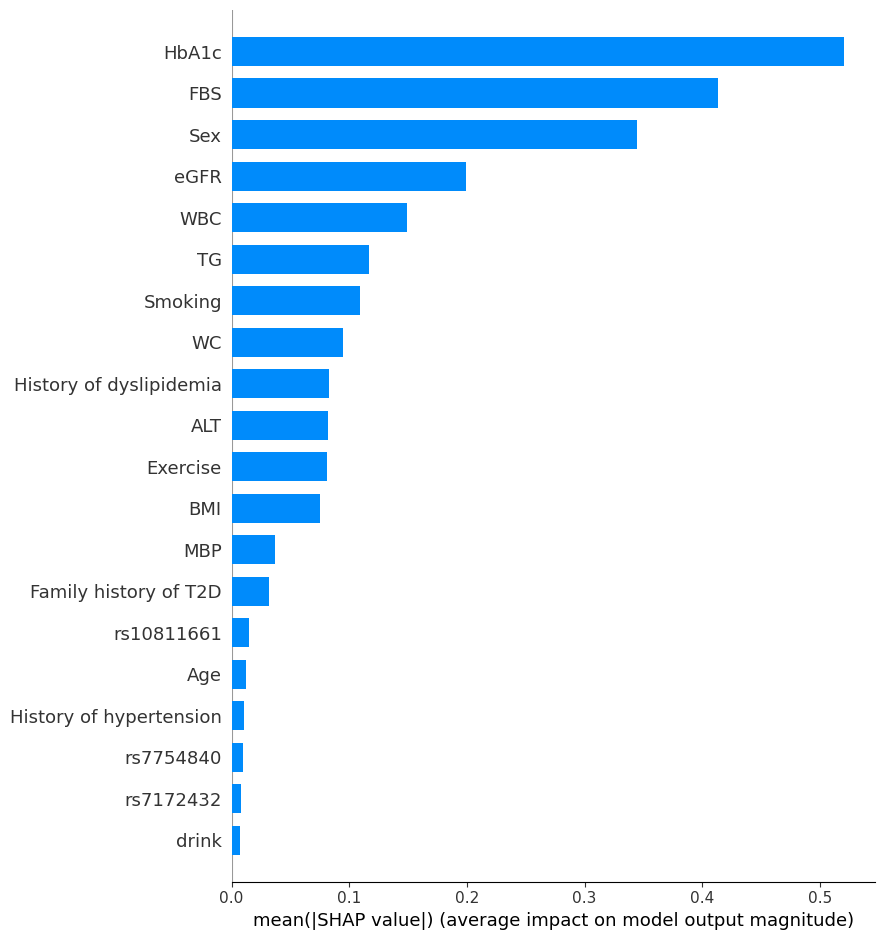

In [73]:
plt.figure(figsize=(10, 7))  # ← 원하는 크기로 조정 (단위: inch)
shap.summary_plot(
    np.array(shap_data2.iloc[:, :-2]),
    np.array(nor_pd),
    feature_names=shap_data2.iloc[:, :-2].columns,
    plot_type='bar',
    show=False  # ★ 중요: 바로 표시하지 않고 레이아웃 조정 가능하게 함
)
plt.subplots_adjust(right=1.1)  
plt.show()

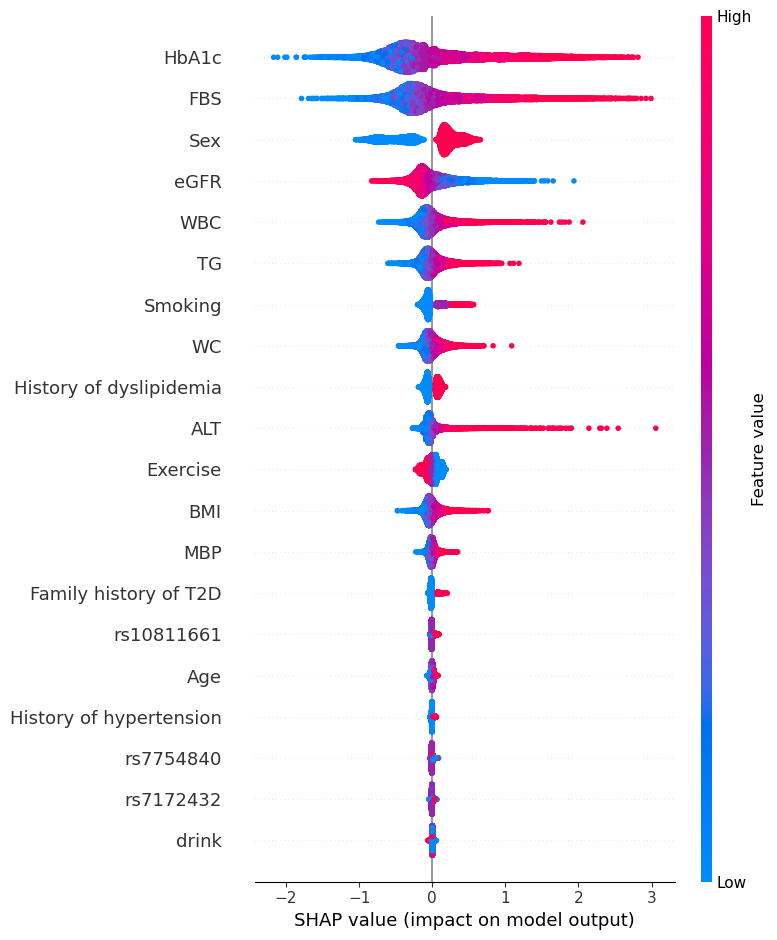

<Figure size 640x480 with 0 Axes>

In [74]:
plt.figure(figsize=(10, 7))  # ← 원하는 크기로 조정 (단위: inch)
shap.summary_plot(np.array(shap_data2.iloc[:,:-2]),np.array(nor_pd), feature_names=shap_data2.iloc[:,:-2].columns)
plt.subplots_adjust(right=1.1)  
plt.show()

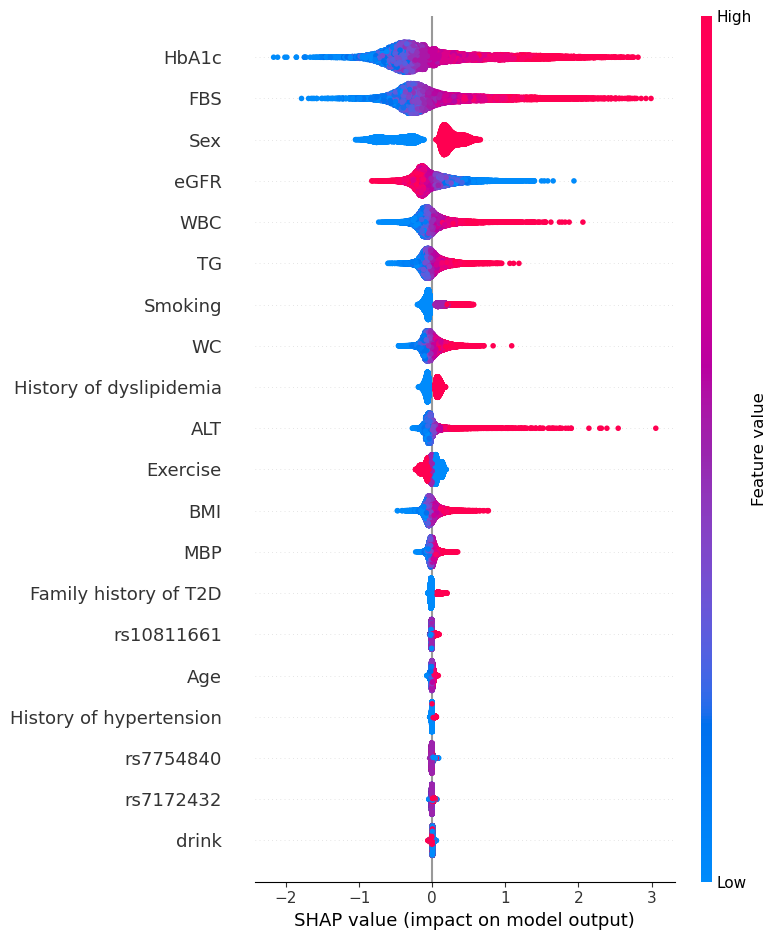

In [52]:
shap.summary_plot(np.array(shap_data2.iloc[:,:-2]),np.array(nor_pd), feature_names=shap_data2.iloc[:,:-2].columns)

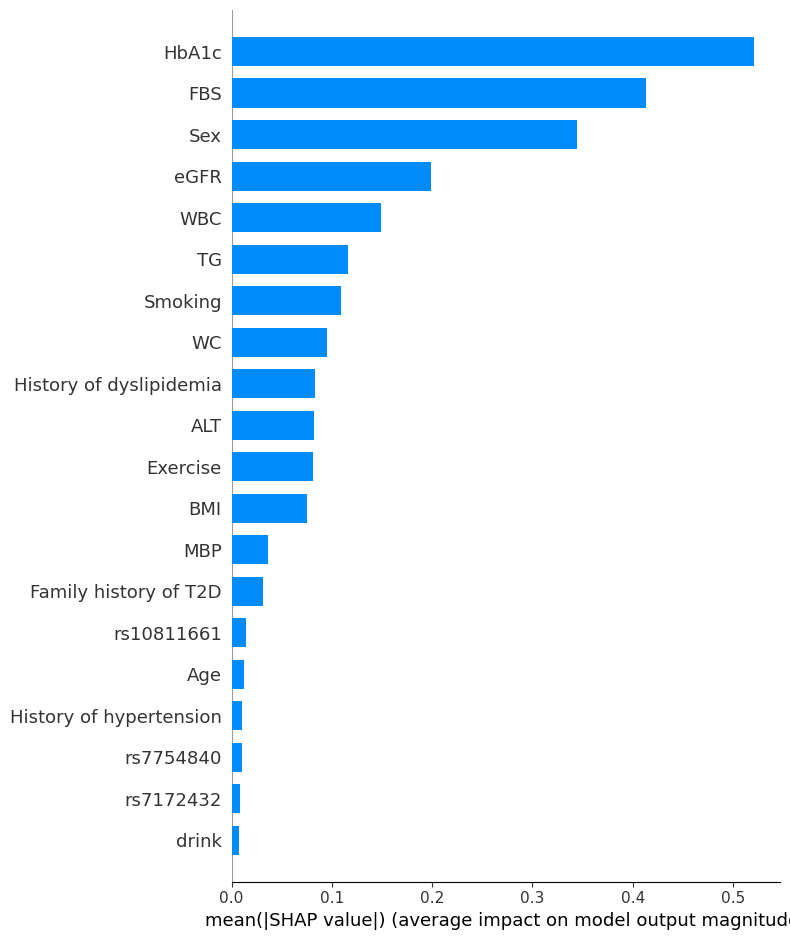

In [53]:
shap.summary_plot(np.array(shap_data2.iloc[:,:-2]),np.array(nor_pd), feature_names=shap_data2.iloc[:,:-2].columns,plot_type='bar')